<a href="https://colab.research.google.com/github/bertramwooster/deep-learning-with-python-notebooks/blob/my-notebook-experiments/chapter03_introduction-to-ml-frameworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [1]:
import sys
if "google.colab" in sys.modules:
    !uv pip install keras keras-hub --upgrade -q

In [2]:
import os
os.environ["KERAS_BACKEND"] = "torch"

In [3]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Introduction to TensorFlow, PyTorch, JAX, and Keras

### A brief history of deep learning frameworks

### How these frameworks relate to each other

### Introduction to TensorFlow

#### First steps with TensorFlow

##### Tensors and variables in TensorFlow

###### Constant tensors

In [ ]:
import tensorflow as tf
tf.ones(shape=(2, 1))

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[1.],
       [1.]], dtype=float32)>

In [ ]:
tf.zeros(shape=(2, 1))

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[0.],
       [0.]], dtype=float32)>

In [ ]:
tf.constant([1, 2, 3], dtype="float32")

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([1., 2., 3.], dtype=float32)>

###### Random tensors

In [ ]:
x = tf.random.normal(shape=(10, 1), mean=0., stddev=1.)
print(x)

tf.Tensor(
[[ 0.40983015]
 [ 0.15178321]
 [ 0.3675578 ]
 [ 0.39230746]
 [-2.4558213 ]
 [-0.439304  ]
 [-1.6557802 ]
 [ 0.06936748]
 [-0.26811972]
 [-0.76209164]], shape=(10, 1), dtype=float32)


In [ ]:
x = tf.random.uniform(shape=(3, 1), minval=0., maxval=1.)
print(x)

tf.Tensor(
[[0.195876  ]
 [0.06698096]
 [0.5663732 ]], shape=(3, 1), dtype=float32)


In [ ]:
# tf.random.uniform can be used to generate random integers by specifying an integer dtype
tf.random.uniform(shape=(3, 2, 2), minval=0, maxval=10, dtype=tf.int32)

<tf.Tensor: shape=(3, 2, 2), dtype=int32, numpy=
array([[[1, 3],
        [8, 6]],

       [[5, 2],
        [6, 9]],

       [[0, 2],
        [7, 1]]], dtype=int32)>

###### Tensor assignment and the Variable class

In [ ]:
import numpy as np

x = np.ones(shape=(2, 2))
x[0, 0] = 0.0

In [ ]:
v = tf.Variable(initial_value=tf.random.normal(shape=(3, 1)))
print(v)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[ 0.08610028],
       [-1.2372004 ],
       [ 0.5751224 ]], dtype=float32)>


In [ ]:
v.assign(tf.ones((3, 1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[1.],
       [1.],
       [1.]], dtype=float32)>

In [ ]:
v[0, 0].assign(3.)

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[3.],
       [1.],
       [1.]], dtype=float32)>

In [ ]:
v.assign_add(tf.ones((3, 1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[4.],
       [2.],
       [2.]], dtype=float32)>

In [ ]:
print(v)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[4.],
       [2.],
       [2.]], dtype=float32)>


##### Tensor operations: Doing math in TensorFlow

In [ ]:
a = tf.ones((2, 2))
b = tf.square(a)
c = tf.sqrt(a)
d = b + c
e = tf.matmul(a, b)
f = tf.concat((a, b), axis=1)
print(e, f)

tf.Tensor(
[[2. 2.]
 [2. 2.]], shape=(2, 2), dtype=float32) tf.Tensor(
[[1. 1. 1. 1.]
 [1. 1. 1. 1.]], shape=(2, 4), dtype=float32)


In [ ]:
tf.matmul(a, tf.reshape(b[:,1], shape = (2,1)))

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[2.],
       [2.]], dtype=float32)>

In [ ]:
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

In [ ]:
a = tf.constant(range(1,7), shape = (2,3))
b = tf.constant(range(1,7), shape = (3,2))
print(a)
print(b)
c = tf.matmul(a,b)
print(c)

tf.Tensor(
[[1 2 3]
 [4 5 6]], shape=(2, 3), dtype=int32)
tf.Tensor(
[[1 2]
 [3 4]
 [5 6]], shape=(3, 2), dtype=int32)
tf.Tensor(
[[22 28]
 [49 64]], shape=(2, 2), dtype=int32)


In [ ]:
print(dense(tf.constant([[1.]]), tf.constant([[1., -1., 0.]]),
      tf.constant([[1., 1., 1.]])))

tf.Tensor([[2. 0. 1.]], shape=(1, 3), dtype=float32)


##### Gradients in TensorFlow: A second look at the GradientTape API

In [ ]:
input_var = tf.Variable(initial_value=13.0)
with tf.GradientTape() as tape:
    result = tf.square(input_var)
gradient = tape.gradient(result, input_var)
print(gradient.numpy())

26.0


In [ ]:
input_const = tf.constant(3.0)
with tf.GradientTape() as tape:
    tape.watch(input_const)
    result = tf.square(input_const)
gradient = tape.gradient(result, input_const)

In [ ]:
time = tf.Variable(1.0)
with tf.GradientTape() as outer_tape:
    with tf.GradientTape() as inner_tape:
        position = 4.9 * time**2
    speed = inner_tape.gradient(position, time)
acceleration = outer_tape.gradient(speed, time)
print(f'At time = {time.numpy()} s, v = {speed.numpy():.2f} m/s \
and a = {acceleration.numpy():.2f} m/s**2')

At time = 1.0 s, v = 9.80 m/s and a = 9.80 m/s**2


##### Making TensorFlow functions fast using compilation

In [ ]:
@tf.function
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

In [ ]:
@tf.function(jit_compile=True)
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

#### An end-to-end example: A linear classifier in pure TensorFlow

In [4]:
import numpy as np

num_samples_per_class = 1000
negative_samples = np.random.multivariate_normal(
    mean=[0, 3], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)
positive_samples = np.random.multivariate_normal(
    mean=[3, 0], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)

In [5]:
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

In [6]:
targets = np.vstack(
    (
        np.zeros((num_samples_per_class, 1), dtype="float32"),
        np.ones((num_samples_per_class, 1), dtype="float32"),
    )
)

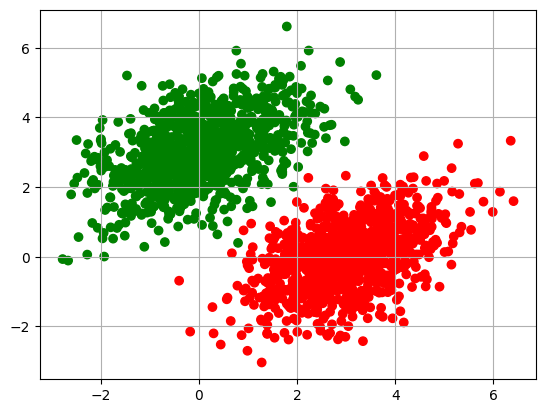

In [7]:
import matplotlib.pyplot as plt
import numpy as np # Import numpy

# Create a list of colors based on the targets
colors = np.where(targets[:, 0] == 0, 'green', 'red')

plt.scatter(inputs[:, 0], inputs[:, 1], c=colors)
plt.grid(True)
plt.show()

In [ ]:
input_dim = 2
output_dim = 1
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

In [ ]:
def model(inputs, W, b):
    return tf.matmul(inputs, W) + b

In [ ]:
def mean_squared_error(targets, predictions):
    per_sample_losses = tf.square(targets - predictions)
    return tf.reduce_mean(per_sample_losses)

In [ ]:
learning_rate = 0.1

@tf.function(jit_compile=True)
def training_step(inputs, targets, W, b):
    with tf.GradientTape() as tape:
        predictions = model(inputs, W, b)
        loss = mean_squared_error(predictions, targets)
    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])
    W.assign_sub(grad_loss_wrt_W * learning_rate)
    b.assign_sub(grad_loss_wrt_b * learning_rate)
    return loss

In [ ]:
loss = []
for step in range(40):
    loss.append(training_step(inputs, targets, W, b))
    print(f"Loss at step {step}: {loss[step]:.4f}")

Loss at step 0: 5.9083
Loss at step 1: 0.8127
Loss at step 2: 0.2390
Loss at step 3: 0.1520
Loss at step 4: 0.1320
Loss at step 5: 0.1217
Loss at step 6: 0.1134
Loss at step 7: 0.1060
Loss at step 8: 0.0992
Loss at step 9: 0.0930
Loss at step 10: 0.0873
Loss at step 11: 0.0821
Loss at step 12: 0.0773
Loss at step 13: 0.0729
Loss at step 14: 0.0689
Loss at step 15: 0.0653
Loss at step 16: 0.0619
Loss at step 17: 0.0588
Loss at step 18: 0.0560
Loss at step 19: 0.0535
Loss at step 20: 0.0511
Loss at step 21: 0.0489
Loss at step 22: 0.0470
Loss at step 23: 0.0452
Loss at step 24: 0.0435
Loss at step 25: 0.0420
Loss at step 26: 0.0406
Loss at step 27: 0.0393
Loss at step 28: 0.0382
Loss at step 29: 0.0371
Loss at step 30: 0.0361
Loss at step 31: 0.0352
Loss at step 32: 0.0344
Loss at step 33: 0.0337
Loss at step 34: 0.0330
Loss at step 35: 0.0323
Loss at step 36: 0.0318
Loss at step 37: 0.0312
Loss at step 38: 0.0308
Loss at step 39: 0.0303


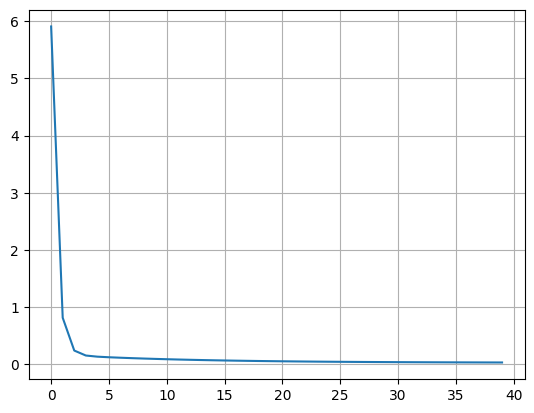

In [ ]:
from matplotlib import pyplot as plt
plt.plot(loss)
plt.grid()
plt.show()

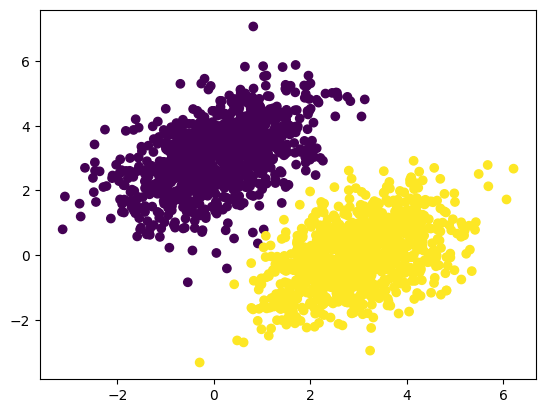

In [ ]:
predictions = model(inputs, W, b)
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()

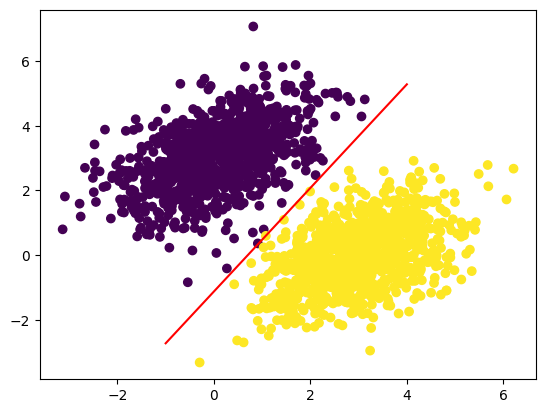

In [ ]:
x = np.linspace(-1, 4, 100)
y = -W[0] / W[1] * x + (0.5 - b) / W[1]
plt.plot(x, y, "-r")
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)

#### What makes the TensorFlow approach unique

### Introduction to PyTorch

#### First steps with PyTorch

##### Tensors and parameters in PyTorch

###### Constant tensors

In [ ]:
import torch
torch.ones(size=(2, 1))

tensor([[1.],
        [1.]])

In [ ]:
torch.zeros(size=(2, 1))

tensor([[0.],
        [0.]])

In [ ]:
torch.tensor(range(6), dtype=torch.float32).reshape(3, 2)

tensor([[0., 1.],
        [2., 3.],
        [4., 5.]])

###### Random tensors

In [ ]:
torch.normal(mean=torch.zeros(size=(6, 1)),
             std=torch.tensor(range(6), dtype=torch.float32).reshape(6, 1))
             #ones(size=(3, 1)))

tensor([[ 0.0000],
        [-0.6034],
        [ 0.9382],
        [-0.5458],
        [-4.7271],
        [11.6936]])

In [ ]:
# Mean of the distribution
mean = torch.zeros(2)

# Covariance matrix for a bivariate normal distribution with correlation 0.5
# The diagonal elements are the variances (here set to 1), and the off-diagonal
# elements are the covariances (correlation * sqrt(variance1 * variance2) = 0.5 * sqrt(1*1) = 0.5)
covariance_matrix = torch.tensor([[1.0, 0.5],
                                  [0.5, 1.0]])

# Create the multivariate normal distribution
m = torch.distributions.MultivariateNormal(mean, covariance_matrix)

# Generate 3 samples
samples = m.sample((3, ))
print(samples)

tensor([[-0.1669, -0.0802],
        [ 1.9228,  2.1514],
        [ 2.2215,  1.8041]])


In [ ]:
torch.rand(3, 1)

tensor([[0.8376],
        [0.8233],
        [0.6902]])

###### Tensor assignment and the Parameter class

In [ ]:
x = torch.zeros(size=(2, 1))
x[0, 0] = 1.
x

tensor([[1.],
        [0.]])

In [ ]:
x = torch.zeros(size=(2, 1))
p = torch.nn.parameter.Parameter(data=x)

##### Tensor operations: Doing math in PyTorch

In [ ]:
a = torch.ones((2, 2))
b = torch.square(a)
c = torch.sqrt(a)
d = b + c
e = torch.matmul(a, b)
f = torch.cat((a, b), dim=0)

In [ ]:
def dense(inputs, W, b):
    return torch.nn.relu(torch.matmul(inputs, W) + b)

##### Computing gradients with PyTorch

In [ ]:
input_var = torch.tensor(3.0, requires_grad=True)
result = torch.square(input_var)
result.backward()
gradient = input_var.grad
gradient

tensor(6.)

In [ ]:
result = torch.square(input_var)
result.backward()
input_var.grad

tensor(6.)

In [ ]:
input_var.grad = None

#### An end-to-end example: A linear classifier in pure PyTorch

In [ ]:
input_dim = 2
output_dim = 1

W = torch.rand(input_dim, output_dim, requires_grad=True)
b = torch.zeros(output_dim, requires_grad=True)

In [ ]:
def model(inputs, W, b):
    return torch.matmul(inputs, W) + b

In [ ]:
def mean_squared_error(targets, predictions):
    per_sample_losses = torch.square(targets - predictions)
    return torch.mean(per_sample_losses)

In [ ]:
learning_rate = 0.1

def training_step(inputs, targets, W, b):
    predictions = model(inputs, W, b)
    loss = mean_squared_error(targets, predictions)
    loss.backward()
    grad_loss_wrt_W, grad_loss_wrt_b = W.grad, b.grad

    # We wrap the update in torch.no_grad() so that the update
    # logic isn't tracked by the computational graph.
    with torch.no_grad():
        W -= grad_loss_wrt_W * learning_rate
        b -= grad_loss_wrt_b * learning_rate

    W.grad = None
    b.grad = None
    return loss

In [ ]:
loss = []
torch_inputs = torch.tensor(inputs)
torch_targets = torch.tensor(targets)
for step in range(40):
    loss.append(training_step(torch_inputs, torch_targets, W, b))
    print(f"Loss at step {step}: {loss[step]:.4f}")

Loss at step 0: 0.6004
Loss at step 1: 0.1605
Loss at step 2: 0.1050
Loss at step 3: 0.0927
Loss at step 4: 0.0862
Loss at step 5: 0.0809
Loss at step 6: 0.0761
Loss at step 7: 0.0717
Loss at step 8: 0.0677
Loss at step 9: 0.0640
Loss at step 10: 0.0607
Loss at step 11: 0.0576
Loss at step 12: 0.0548
Loss at step 13: 0.0522
Loss at step 14: 0.0499
Loss at step 15: 0.0477
Loss at step 16: 0.0458
Loss at step 17: 0.0440
Loss at step 18: 0.0423
Loss at step 19: 0.0408
Loss at step 20: 0.0394
Loss at step 21: 0.0382
Loss at step 22: 0.0370
Loss at step 23: 0.0359
Loss at step 24: 0.0350
Loss at step 25: 0.0341
Loss at step 26: 0.0333
Loss at step 27: 0.0325
Loss at step 28: 0.0318
Loss at step 29: 0.0312
Loss at step 30: 0.0307
Loss at step 31: 0.0301
Loss at step 32: 0.0297
Loss at step 33: 0.0292
Loss at step 34: 0.0288
Loss at step 35: 0.0285
Loss at step 36: 0.0281
Loss at step 37: 0.0278
Loss at step 38: 0.0275
Loss at step 39: 0.0273


##### Packaging state and computation with the Module class

In [ ]:
class LinearModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.W = torch.nn.Parameter(torch.rand(input_dim, output_dim))
        self.b = torch.nn.Parameter(torch.zeros(output_dim))

    def forward(self, inputs):
        return torch.matmul(inputs, self.W) + self.b

In [ ]:
model = LinearModel()

In [ ]:
#torch_inputs = torch.tensor(inputs)
output = model(torch_inputs)

In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [ ]:
def training_step(inputs, targets):
    predictions = model(inputs)
    loss = mean_squared_error(targets, predictions)
    loss.backward()
    optimizer.step()
    model.zero_grad()
    return loss

In [ ]:
loss = []
for step in range(40):
    loss.append(training_step(torch_inputs, torch_targets))
    print(f"Loss at step {step}: {loss[step]:.4f}")

Loss at step 0: 7.0302
Loss at step 1: 0.9199
Loss at step 2: 0.2559
Loss at step 3: 0.1631
Loss at step 4: 0.1423
Loss at step 5: 0.1312
Loss at step 6: 0.1220
Loss at step 7: 0.1137
Loss at step 8: 0.1061
Loss at step 9: 0.0992
Loss at step 10: 0.0929
Loss at step 11: 0.0871
Loss at step 12: 0.0818
Loss at step 13: 0.0769
Loss at step 14: 0.0725
Loss at step 15: 0.0684
Loss at step 16: 0.0647
Loss at step 17: 0.0613
Loss at step 18: 0.0582
Loss at step 19: 0.0553
Loss at step 20: 0.0527
Loss at step 21: 0.0503
Loss at step 22: 0.0481
Loss at step 23: 0.0461
Loss at step 24: 0.0443
Loss at step 25: 0.0426
Loss at step 26: 0.0411
Loss at step 27: 0.0397
Loss at step 28: 0.0384
Loss at step 29: 0.0372
Loss at step 30: 0.0361
Loss at step 31: 0.0351
Loss at step 32: 0.0342
Loss at step 33: 0.0334
Loss at step 34: 0.0327
Loss at step 35: 0.0320
Loss at step 36: 0.0313
Loss at step 37: 0.0308
Loss at step 38: 0.0302
Loss at step 39: 0.0297


##### Making PyTorch modules fast using compilation

In [ ]:
compiled_model = torch.compile(model)

In [ ]:
@torch.compile
def dense(inputs, W, b):
    return torch.nn.relu(torch.matmul(inputs, W) + b)

#### What makes the PyTorch approach unique

### Introduction to JAX

#### First steps with JAX

#### Tensors in JAX

In [ ]:
from jax import numpy as jnp
jnp.ones(shape=(2, 1))

Array([[1.],
       [1.]], dtype=float32)

In [ ]:
jnp.zeros(shape=(2, 1))

Array([[0.],
       [0.]], dtype=float32)

In [ ]:
jnp.full(shape=(2, 1), fill_value = .2)

Array([[0.2],
       [0.2]], dtype=float32, weak_type=True)

In [ ]:
jnp.array([1, 2, 3], dtype="float32")

Array([1., 2., 3.], dtype=float32)

#### Random number generation in JAX

In [ ]:
import numpy as np
np.random.normal(size=(3,))

array([-0.83390806,  1.18365285, -2.6038633 ])

In [ ]:
np.random.normal(size=(3,))

array([ 0.75321623,  0.81494469, -1.94372609])

In [ ]:
def apply_noise(x, seed):
    np.random.seed(seed)
    x = x * np.random.normal((3,))
    return x

seed = 1337
x = np.random.normal(size=(3,))
y = apply_noise(x, seed)
seed += 0
z = apply_noise(x, seed)
print(x,y,z)

[ 0.06905289 -1.36994721 -1.73542443] [ 0.15860155 -3.14651214 -3.98594485] [ 0.15860155 -3.14651214 -3.98594485]


In [ ]:
import jax

seed_key = jax.random.key(1337)

In [ ]:
seed_key = jax.random.key(0)
jax.random.normal(seed_key, shape=(3,))

Array([ 1.6226422 ,  2.0252647 , -0.43359444], dtype=float32)

In [ ]:
seed_key = jax.random.key(123)
jax.random.normal(seed_key, shape=(3,))

Array([1.6359469 , 0.8408094 , 0.02212393], dtype=float32)

In [ ]:
jax.random.normal(seed_key, shape=(3,))

Array([1.6359469 , 0.8408094 , 0.02212393], dtype=float32)

In [ ]:
seed_key = jax.random.key(123)
jax.random.normal(seed_key, shape=(3,))

Array([1.6359469 , 0.8408094 , 0.02212393], dtype=float32)

In [ ]:
new_seed_key_list = jax.random.split(seed_key, num=6)#[0]
#jax.random.normal(new_seed_key, shape=(3,))
print(f'We are gen {len(new_seed_key_list)} random arrays')
for new_seed_key in new_seed_key_list:
    print()
    print(jax.random.normal(new_seed_key, shape=(3,)))

We are gen 6 random arrays

[-0.49093357 -0.9478693  -1.775197  ]

[-0.7828054 -1.5373377 -0.5513038]

[-0.903396   1.089539  -1.1968036]

[2.4205756 0.1779215 0.5011102]

[ 0.52137166 -0.1863865   1.2542883 ]

[ 0.69527596 -0.5525624  -1.2247187 ]


In [ ]:
type(new_seed_key_list)

jax._src.prng.PRNGKeyArray

##### Tensor assignment

In [ ]:
x = jnp.array([1, 2, 3], dtype="float32")
new_x = x.at[0].set(10)
new_x

Array([10.,  2.,  3.], dtype=float32)

##### Tensor operations: Doing math in JAX

In [ ]:
a = jnp.ones((2, 2))
b = jnp.square(a)
c = jnp.sqrt(a)
d = b + c
e = jnp.matmul(a, b)
e *= d

In [ ]:
def dense(inputs, W, b):
    return jax.nn.relu(jnp.matmul(inputs, W) + b)

##### Computing gradients with JAX

In [ ]:
def compute_loss(input_var):
    return jnp.square(input_var) + jnp.sqrt(jnp.abs(input_var))

In [ ]:
grad_fn = jax.grad(compute_loss)

In [ ]:
input_var = jnp.array(3.0)
grad_of_loss_wrt_input_var = grad_fn(input_var)

##### JAX gradient-computation best practices

###### Returning the loss value

In [ ]:
input_var = jnp.array(-1.)
grad_fn = jax.value_and_grad(compute_loss)
output, grad_of_loss_wrt_input_var = grad_fn(input_var )
print(f'Loss is {output} when input is {input_var}\
      and grad is {grad_of_loss_wrt_input_var}')

Loss is 2.0 when input is -1.0      and grad is -2.5


###### Getting gradients for a complex function

###### Returning auxiliary outputs

##### Making JAX functions fast with @jax.jit

In [ ]:
@jax.jit
def dense(inputs, W, b):
    return jax.nn.relu(jnp.matmul(inputs, W) + b)

#### An end-to-end example: A linear classifier in pure JAX

In [ ]:
def model(inputs, W, b):
    return jnp.matmul(inputs, W) + b

def mean_squared_error(targets, predictions):
    per_sample_losses = jnp.square(targets - predictions)
    return jnp.mean(per_sample_losses)

In [ ]:
def compute_loss(state, inputs, targets):
    W, b = state
    predictions = model(inputs, W, b)
    loss = mean_squared_error(targets, predictions)
    return loss

In [ ]:
grad_fn = jax.value_and_grad(compute_loss)

In [ ]:
learning_rate = 0.1

@jax.jit
def training_step(inputs, targets, W, b):
    loss, grads = grad_fn((W, b), inputs, targets)
    grad_wrt_W, grad_wrt_b = grads
    W = W - grad_wrt_W * learning_rate
    b = b - grad_wrt_b * learning_rate
    return loss, W, b

In [ ]:
input_dim = 2
output_dim = 1

W = jax.numpy.array(np.random.uniform(size=(input_dim, output_dim)))
b = jax.numpy.array(np.zeros(shape=(output_dim,)))
state = (W, b)
for step in range(40):
    loss, W, b = training_step(inputs, targets, W, b)
    print(f"Loss at step {step}: {loss:.4f}")

Loss at step 0: 7.0691
Loss at step 1: 1.3361
Loss at step 2: 0.3714
Loss at step 3: 0.1902
Loss at step 4: 0.1492
Loss at step 5: 0.1338
Loss at step 6: 0.1236
Loss at step 7: 0.1150
Loss at step 8: 0.1072
Loss at step 9: 0.1002
Loss at step 10: 0.0937
Loss at step 11: 0.0878
Loss at step 12: 0.0824
Loss at step 13: 0.0774
Loss at step 14: 0.0729
Loss at step 15: 0.0688
Loss at step 16: 0.0650
Loss at step 17: 0.0615
Loss at step 18: 0.0583
Loss at step 19: 0.0554
Loss at step 20: 0.0528
Loss at step 21: 0.0504
Loss at step 22: 0.0481
Loss at step 23: 0.0461
Loss at step 24: 0.0442
Loss at step 25: 0.0425
Loss at step 26: 0.0410
Loss at step 27: 0.0396
Loss at step 28: 0.0383
Loss at step 29: 0.0371
Loss at step 30: 0.0360
Loss at step 31: 0.0350
Loss at step 32: 0.0341
Loss at step 33: 0.0332
Loss at step 34: 0.0325
Loss at step 35: 0.0318
Loss at step 36: 0.0311
Loss at step 37: 0.0305
Loss at step 38: 0.0300
Loss at step 39: 0.0295


#### What makes the JAX approach unique

### Introduction to Keras

#### First steps with Keras

##### Picking a backend framework

In [1]:
import os

os.environ["KERAS_BACKEND"] = "jax"

import keras

#### Layers: The building blocks of deep learning

##### The base `Layer` class in Keras

In [7]:
import keras

class SimpleDense(keras.Layer):
    def __init__(self, units, activation=None):
        super().__init__()# inherits from base layer
        self.units = units
        self.activation = activation

    def build(self, input_shape):# separte from __init__()cuz of layer shape inference
        batch_dim, input_dim = input_shape# Keras calls this when the layer is first called and gives input_value = inputs.shape
        self.W = self.add_weight(
            shape=(input_dim, self.units), initializer="random_normal"
        )
        self.b = self.add_weight(shape=(self.units,), initializer="zeros")

    def call(self, inputs):
        y = keras.ops.matmul(inputs, self.W) + self.b
        if self.activation is not None:
            y = self.activation(y)
        return y

In [8]:
my_dense = SimpleDense(units=32, activation=keras.ops.relu)#initialisation
input_tensor = keras.ops.ones(shape=(2, 784))
output_tensor = my_dense(input_tensor)#call instance
print(output_tensor.shape)

(2, 32)


##### Automatic shape inference: Building layers on the fly

In [9]:
from keras import layers

layer = layers.Dense(32, activation="relu")

In [10]:
from keras import models
from keras import layers

model = models.Sequential(
    [
        layers.Dense(32, activation="relu"),
        layers.Dense(32),
    ]
)

In [11]:
model = keras.Sequential(
    [
        SimpleDense(32, activation="relu"),
        SimpleDense(64, activation="relu"),
        SimpleDense(32, activation="relu"),
        SimpleDense(10, activation="softmax"),
    ]
)

#### From layers to models

#### The "compile" step: Configuring the learning process

In [12]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(
    optimizer="rmsprop",
    loss="mean_squared_error",
    metrics=["accuracy"],
)

In [13]:
model.compile(
    optimizer=keras.optimizers.RMSprop(),
    loss=keras.losses.MeanSquaredError(),
    metrics=[keras.metrics.BinaryAccuracy()],
)

#### Picking a loss function

#### Understanding the fit method

In [14]:
history = model.fit(
    inputs,
    targets,
    epochs=5,
    batch_size=128,
)

Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - binary_accuracy: 0.8440 - loss: 4.4789
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8605 - loss: 4.2300 
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8730 - loss: 4.0272 
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.8860 - loss: 3.8408
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.8945 - loss: 3.6593


In [15]:
history.history

{'binary_accuracy': [0.843999981880188,
  0.8604999780654907,
  0.8730000257492065,
  0.8859999775886536,
  0.8945000171661377],
 'loss': [4.478885650634766,
  4.229957103729248,
  4.027198314666748,
  3.840813398361206,
  3.659332036972046]}

#### Monitoring loss and metrics on validation data

In [20]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.1),
    loss=keras.losses.MeanSquaredError(),
    metrics=[keras.metrics.BinaryAccuracy()],
)

indices_permutation = np.random.permutation(len(inputs))
shuffled_inputs = inputs[indices_permutation]
shuffled_targets = targets[indices_permutation]

num_validation_samples = int(0.3 * len(inputs))
val_inputs = shuffled_inputs[:num_validation_samples]
val_targets = shuffled_targets[:num_validation_samples]
training_inputs = shuffled_inputs[num_validation_samples:]
training_targets = shuffled_targets[num_validation_samples:]
history = model.fit(
    training_inputs,
    training_targets,
    epochs=5,
    batch_size=16,
    validation_data=(val_inputs, val_targets),
)

Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - binary_accuracy: 0.9207 - loss: 0.1791 - val_binary_accuracy: 1.0000 - val_loss: 0.0276
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9593 - loss: 0.0700 - val_binary_accuracy: 1.0000 - val_loss: 0.0381
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9607 - loss: 0.0733 - val_binary_accuracy: 0.9967 - val_loss: 0.0390
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9557 - loss: 0.0741 - val_binary_accuracy: 0.8450 - val_loss: 0.2779
Epoch 5/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9621 - loss: 0.0727 - val_binary_accuracy: 0.9750 - val_loss: 0.0668


In [21]:
history.history

{'binary_accuracy': [0.920714259147644,
  0.9592857360839844,
  0.9607142806053162,
  0.9557142853736877,
  0.9621428847312927],
 'loss': [0.17910179495811462,
  0.06996947526931763,
  0.07334590703248978,
  0.07411931455135345,
  0.0726982057094574],
 'val_binary_accuracy': [1.0,
  1.0,
  0.996666669845581,
  0.8450000286102295,
  0.9750000238418579],
 'val_loss': [0.027574386447668076,
  0.038142889738082886,
  0.03903486579656601,
  0.27788275480270386,
  0.06679779291152954]}

#### Inference: Using a model after training

In [19]:
predictions = model.predict(val_inputs, batch_size=128)
print(predictions[:10])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[0.35964274]
 [0.9742154 ]
 [1.0970833 ]
 [0.13391978]
 [0.8011466 ]
 [0.13031048]
 [0.7612302 ]
 [0.8252988 ]
 [0.05549267]
 [0.32486743]]
